In [109]:
from shinka.utils import load_programs_to_df

path = "results/results_circle_async_small/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 48
Correct program rows: 47
Total cost: $0.57
Avg cost per program: $0.01
Total prompt rows: 9
Prompts in archive: 9


In [110]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,safe_processing,meta_cost,meta_recommendations,meta_summary,meta_scratch_pad,_spawned_island,_spawned_from_program_id,_spawn_island_idx,_spawn_strategy,total_cost
0,bd321a43-a49d-40c3-ac39-9fe3c0f0b5a4,"from typing import Literal, Tuple\nimport rand...",python,NaN,[],[],0,2026-03-11 20:30:56.743172884,0.719,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,ba9789aa-37d2-4e90-9b92-ffcca3cf9854,"from typing import Literal, Tuple\nimport rand...",python,bd321a43-a49d-40c3-ac39-9fe3c0f0b5a4,[],[],1,2026-03-11 20:32:01.131872891,0.635,[],...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003737
2,ba1b8991-b7b0-482c-91d4-3a213987df85,"from typing import Literal, Tuple\nimport rand...",python,bd321a43-a49d-40c3-ac39-9fe3c0f0b5a4,[],[],2,2026-03-11 20:32:30.967825890,0.635,[],...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003835
3,fadeb311-d339-42a2-9c2a-2302e806db8e,"from typing import Literal, Tuple\nimport rand...",python,ba9789aa-37d2-4e90-9b92-ffcca3cf9854,[bd321a43-a49d-40c3-ac39-9fe3c0f0b5a4],[],3,2026-03-11 20:33:20.817210913,0.702,[],...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005528
4,2a8b52fb-f686-4b47-8797-f95818d8cc6e,"from typing import Literal, Tuple\nimport rand...",python,ba9789aa-37d2-4e90-9b92-ffcca3cf9854,"[ba1b8991-b7b0-482c-91d4-3a213987df85, bd321a4...",[],4,2026-03-11 20:33:51.922133923,0.636,[],...,True,0.013385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019835


Filtered to 47 'correct' rows from 48 total.
GraphViz not available, using hierarchical layout


/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/shinka/plots/plot_lineage_tree.py:398: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred

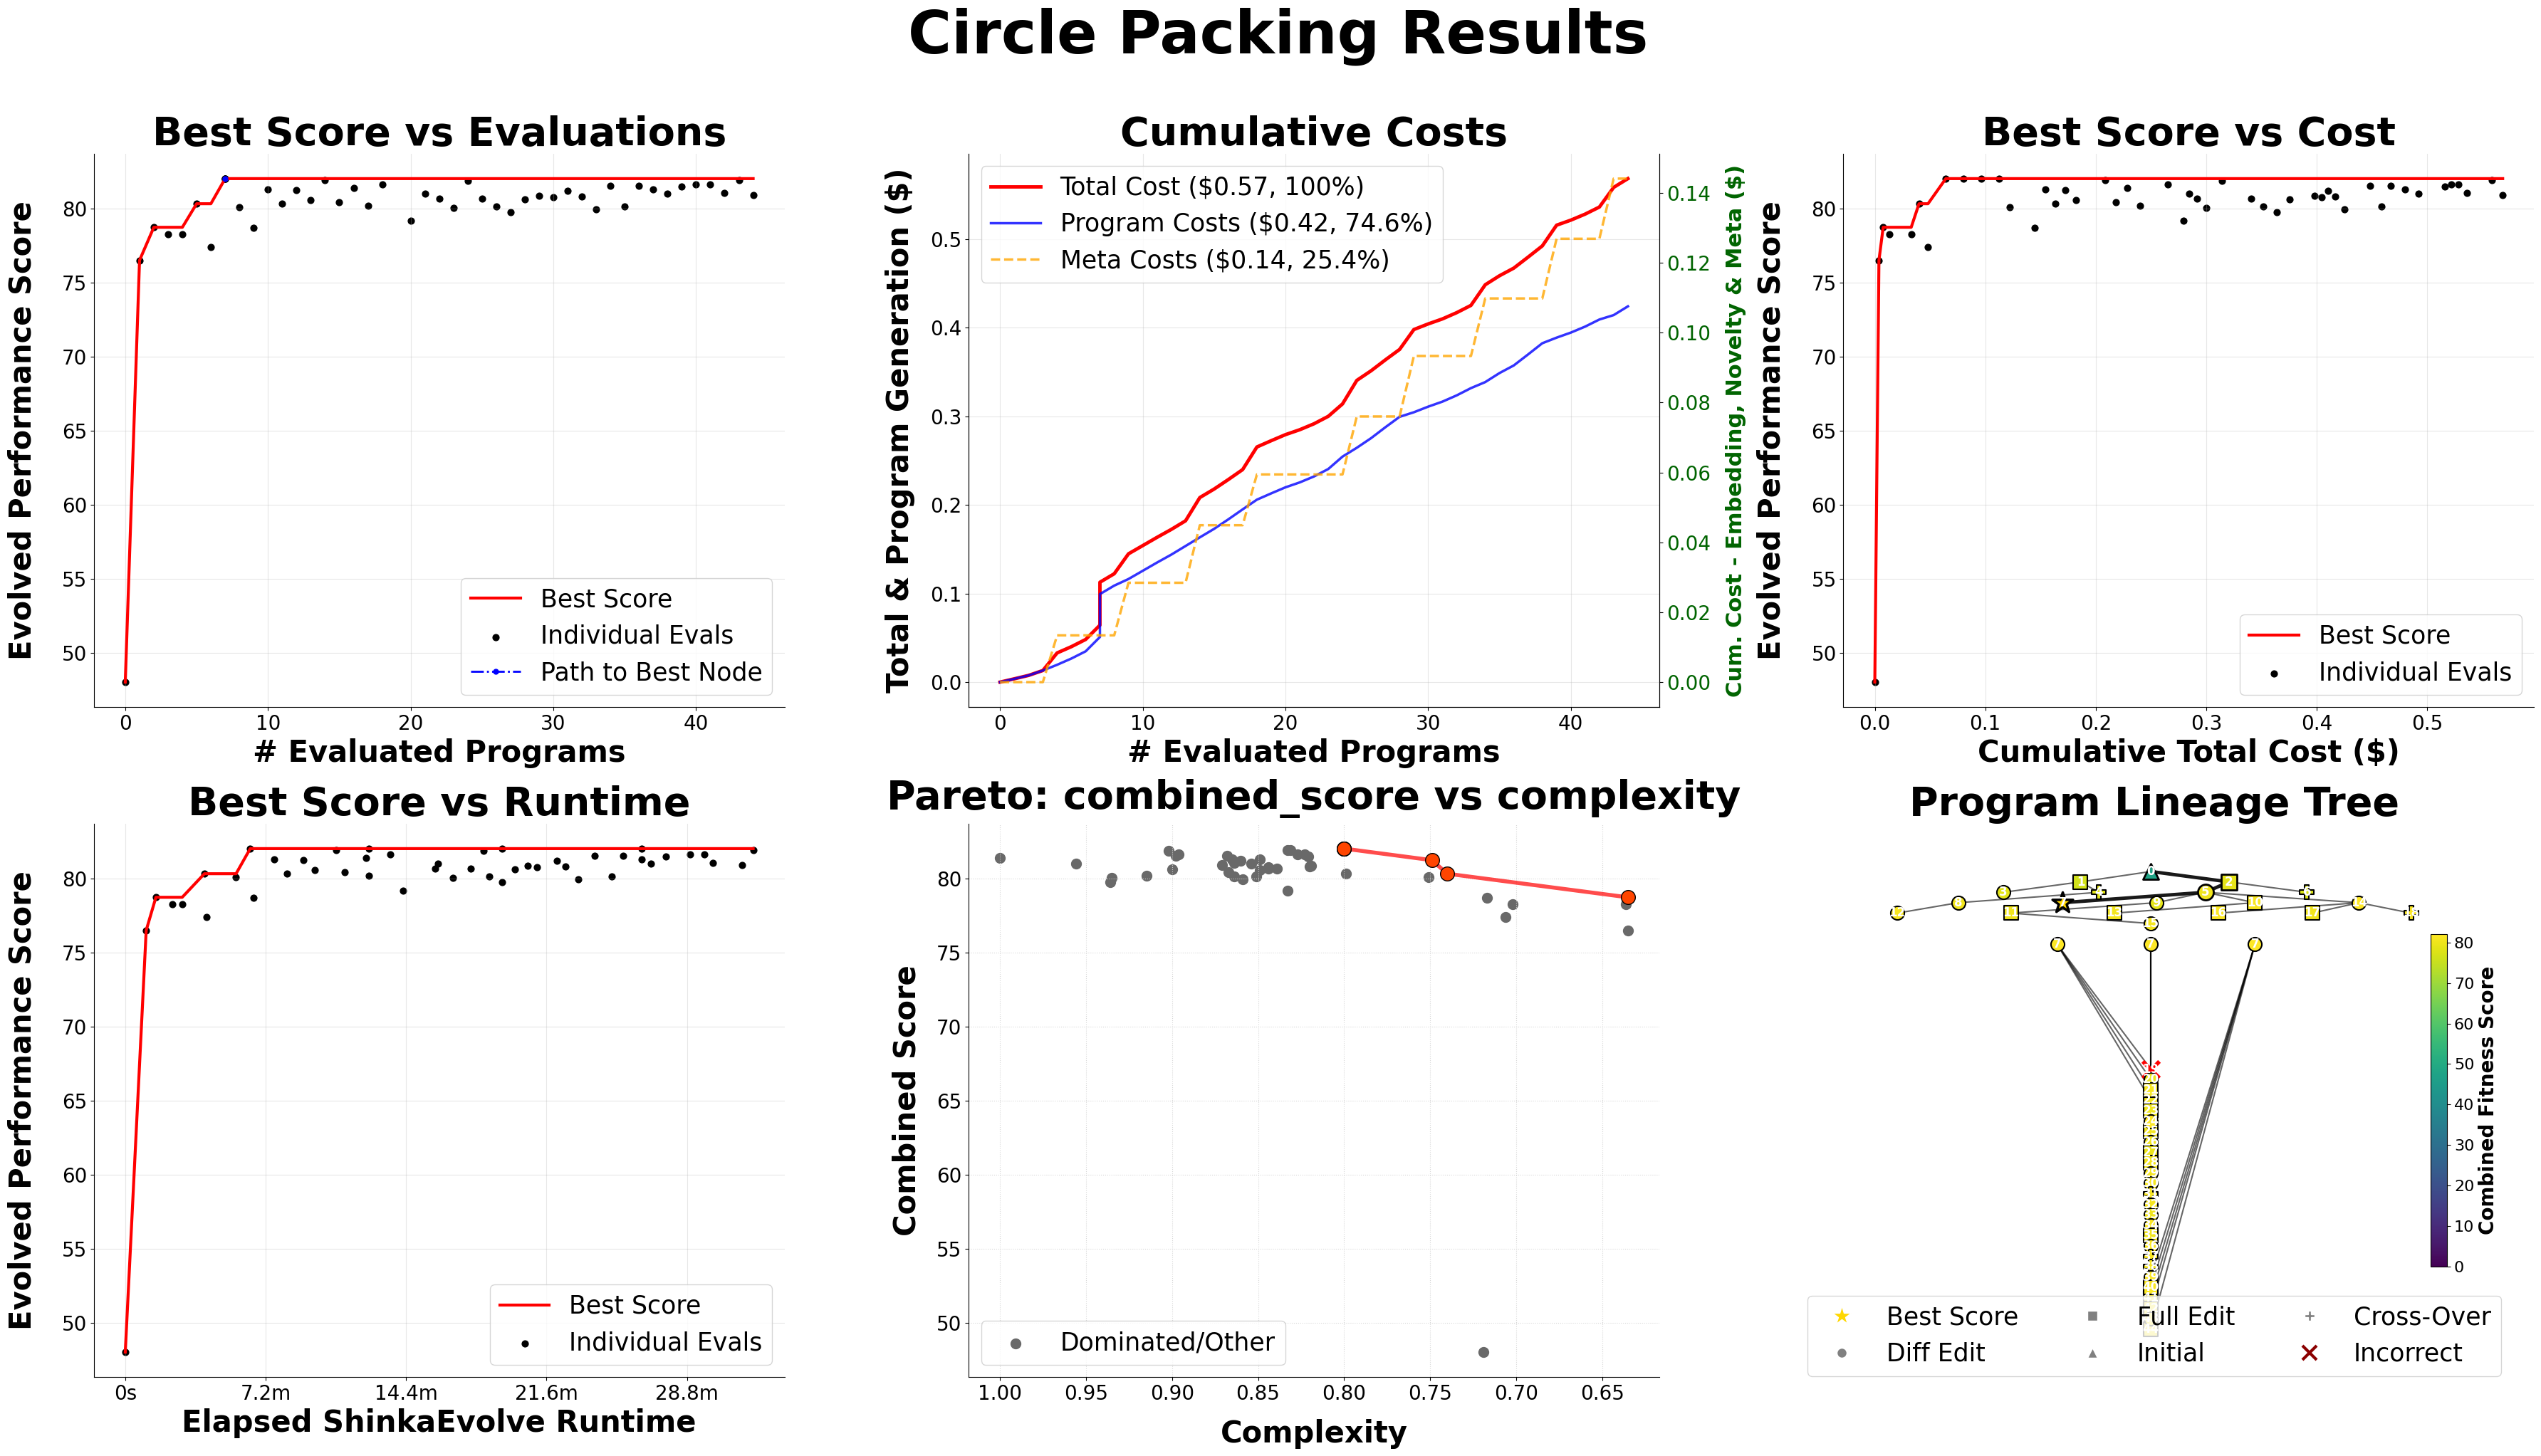

In [111]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("Circle Packing Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

plt.tight_layout()
plt.show()
